# Bank Customer Churn Prediction
## European Bank Dataset — 10,000 Customers

## 1. Importing Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('European_Bank.csv')
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Loading Data

In [30]:
print(df.head)
print(df.shape)
print(df.info())
print(df.isnull().sum())

<bound method NDFrame.head of       Year  CustomerId    Surname  CreditScore Geography  Gender  Age  Tenure  \
0     2025    15634602   Hargrave          619    France  Female   42       2   
1     2025    15647311       Hill          608     Spain  Female   41       1   
2     2025    15619304       Onio          502    France  Female   42       8   
3     2025    15701354       Boni          699    France  Female   39       1   
4     2025    15737888   Mitchell          850     Spain  Female   43       2   
...    ...         ...        ...          ...       ...     ...  ...     ...   
9995  2025    15606229   Obijiaku          771    France    Male   39       5   
9996  2025    15569892  Johnstone          516    France    Male   35      10   
9997  2025    15584532        Liu          709    France  Female   36       7   
9998  2025    15682355  Sabbatini          772   Germany    Male   42       3   
9999  2025    15628319     Walker          792    France  Female   28       4  

## 3. Exploratory Data Analysis (EDA)

### 3.1 Churn Distribution

In [31]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True)*100)

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


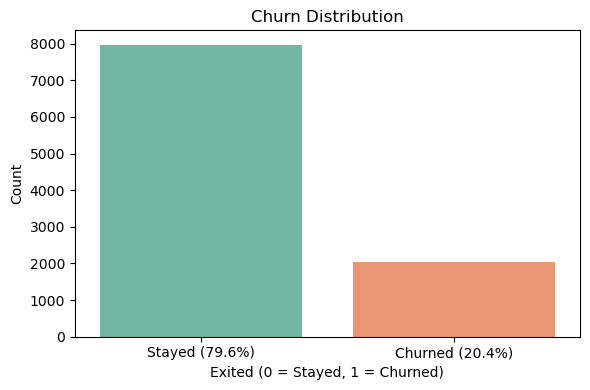

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', hue='Exited', data=df, palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Count')
plt.xticks([0,1], ['Stayed (79.6%)', 'Churned (20.4%)'])
plt.tight_layout()
plt.show()

### 3.2 Geography Analysis

In [33]:
print(df['Geography'].value_counts())
print()
print(df['Gender'].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [34]:
df.groupby('Geography')['Exited'].mean()*100

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

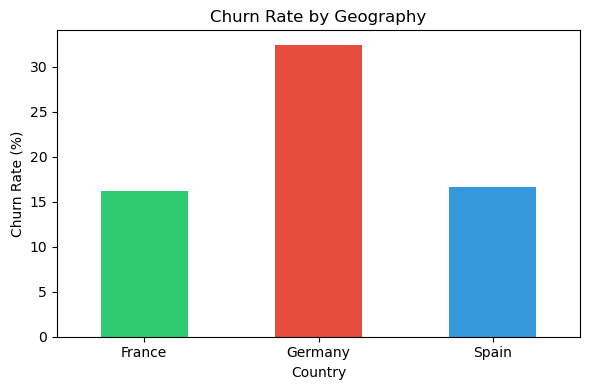

In [35]:
plt.figure(figsize=(6,4))
df.groupby('Geography')['Exited'].mean().mul(100).plot(kind='bar', color=['#2ecc71','#e74c3c','#3498db'])
plt.title('Churn Rate by Geography')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.3 Gender Analysis

In [36]:
df.groupby('Gender')['Exited'].mean()*100

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

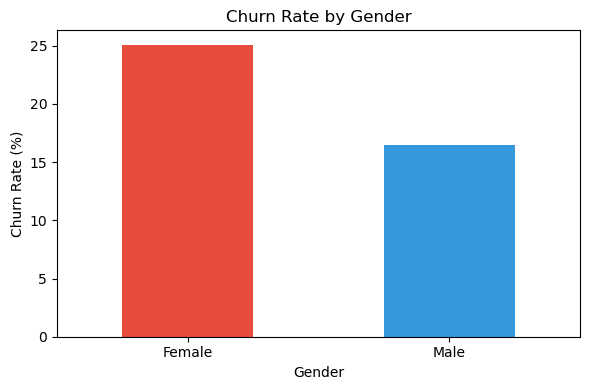

In [37]:
plt.figure(figsize=(6,4))
df.groupby('Gender')['Exited'].mean().mul(100).plot(kind='bar', color=['#e74c3c','#3498db'])
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.4 Age Analysis

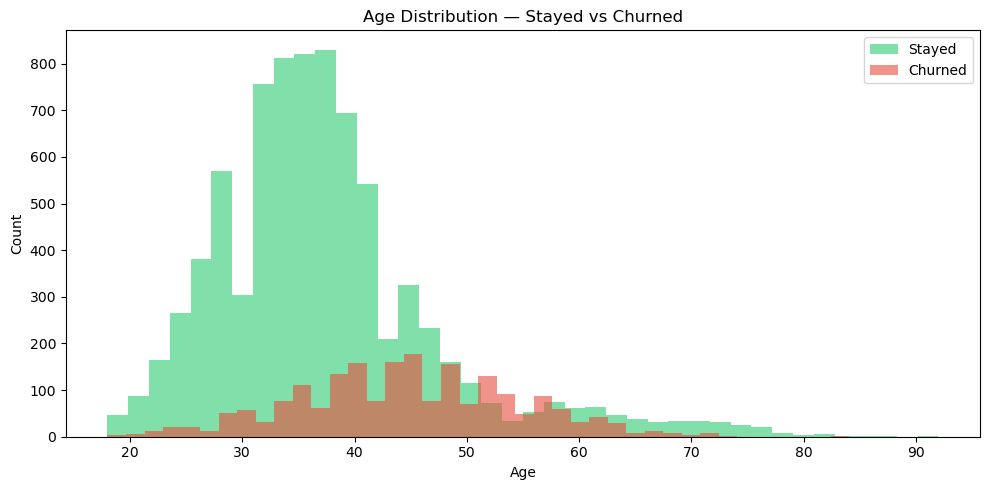

In [38]:
plt.figure(figsize=(10,5))
df[df['Exited']==0]['Age'].plot(kind='hist', bins=40, alpha=0.6, label='Stayed', color='#2ecc71')
df[df['Exited']==1]['Age'].plot(kind='hist', bins=40, alpha=0.6, label='Churned', color='#e74c3c')
plt.title('Age Distribution — Stayed vs Churned')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 Balance Analysis

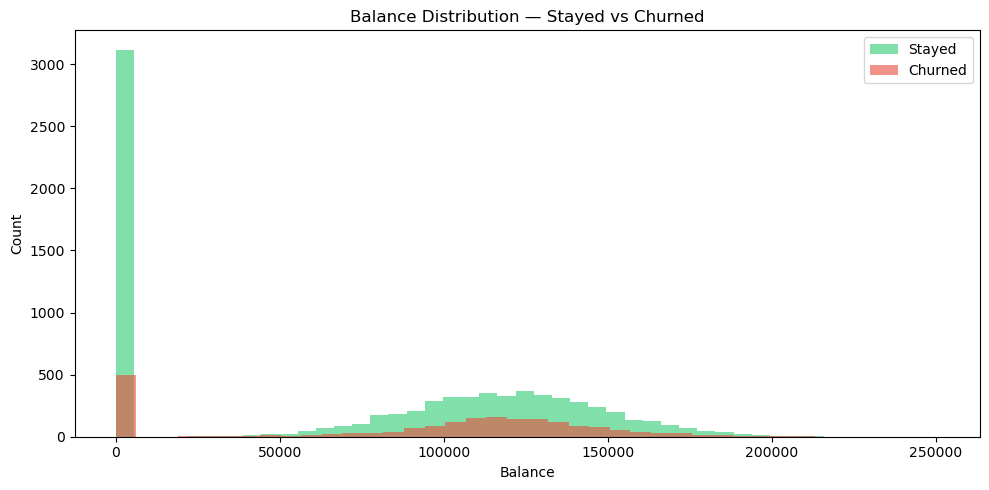

In [39]:
plt.figure(figsize=(10,5))
df[df['Exited']==0]['Balance'].plot(kind='hist', bins=40, alpha=0.6, label='Stayed', color='#2ecc71')
df[df['Exited']==1]['Balance'].plot(kind='hist', bins=40, alpha=0.6, label='Churned', color='#e74c3c')
plt.title('Balance Distribution — Stayed vs Churned')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3.6 NumOfProducts Analysis

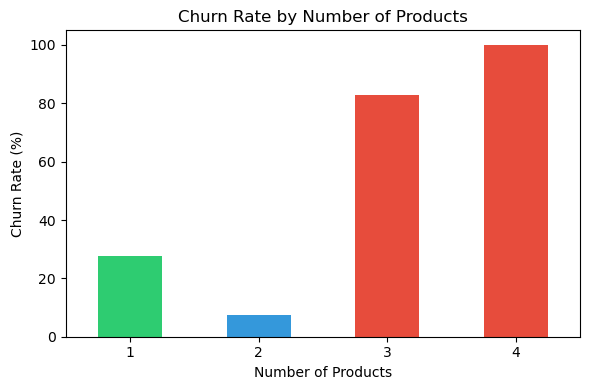

In [40]:
plt.figure(figsize=(6,4))
df.groupby('NumOfProducts')['Exited'].mean().mul(100).plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c','#e74c3c'])
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.7 CreditScore Analysis

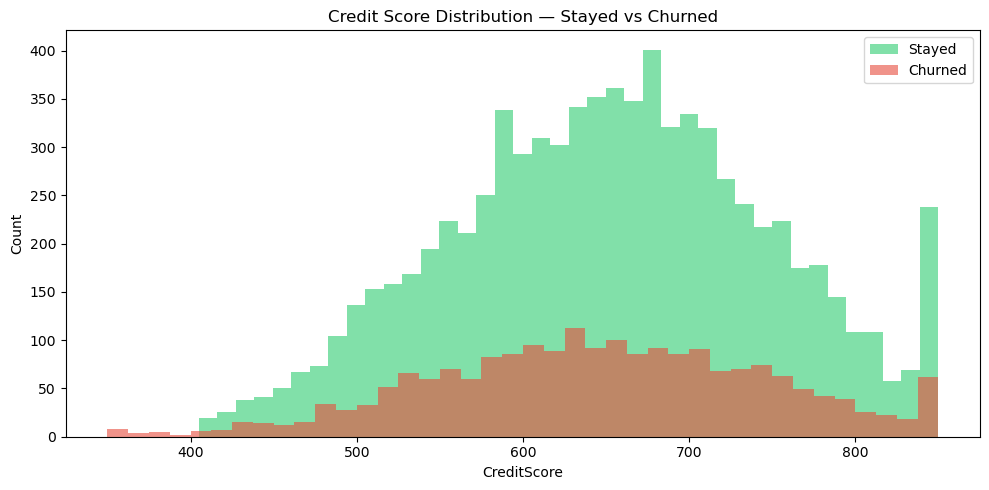

In [41]:
plt.figure(figsize=(10,5))
df[df['Exited']==0]['CreditScore'].plot(kind='hist', bins=40, alpha=0.6, label='Stayed', color='#2ecc71')
df[df['Exited']==1]['CreditScore'].plot(kind='hist', bins=40, alpha=0.6, label='Churned', color='#e74c3c')
plt.title('Credit Score Distribution — Stayed vs Churned')
plt.xlabel('CreditScore')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3.8 IsActiveMember Analysis

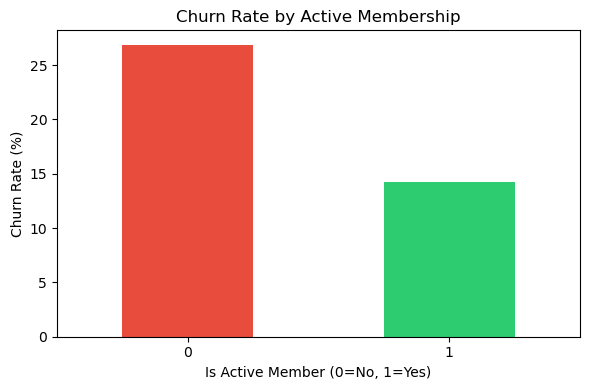

In [42]:
# IsActiveMember
plt.figure(figsize=(6,4))
df.groupby('IsActiveMember')['Exited'].mean().mul(100).plot(kind='bar', color=['#e74c3c','#2ecc71'])
plt.title('Churn Rate by Active Membership')
plt.xlabel('Is Active Member (0=No, 1=Yes)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.9 Tenure Analysis

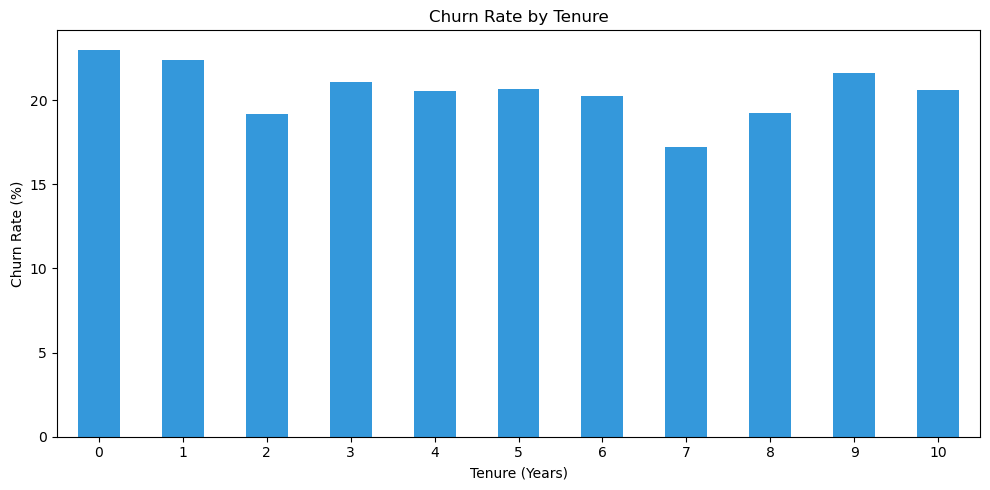

In [43]:
# Tenure
plt.figure(figsize=(10,5))
df.groupby('Tenure')['Exited'].mean().mul(100).plot(kind='bar', color='#3498db')
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.10 Correlation Heatmap

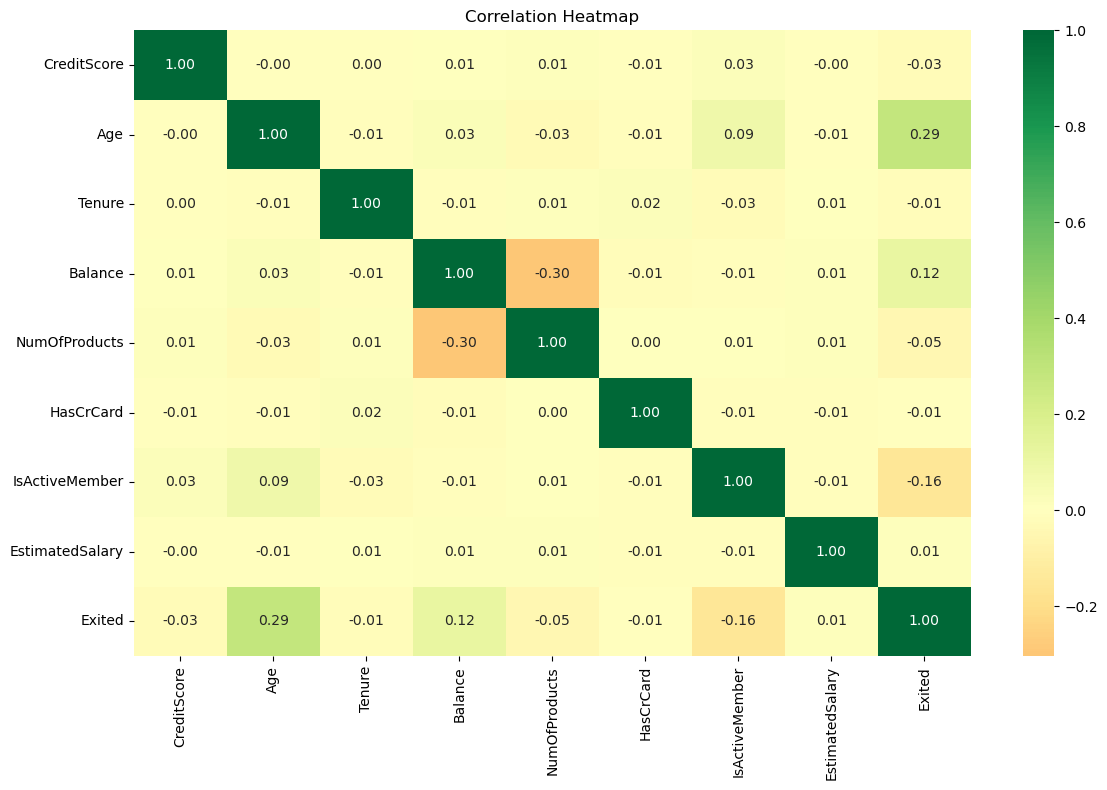

In [44]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number').drop(['CustomerId','Year'], axis=1)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Drop Irrelevant Columns

In [45]:
df_clean = df.drop(['CustomerId', 'Surname', 'Year'], axis=1)
print(df_clean.shape)
df_clean.head()

(10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 4.2 One Hot Encoding (Geography & Gender)

In [46]:
df_clean = pd.get_dummies(df_clean, columns=['Geography', 'Gender'], drop_first=False, dtype=int)
print(df_clean.shape)
df_clean.head()

(10000, 14)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0


### 4.3 Feature Scaling

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Scale numerical columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['CreditScore','Age','Tenure','Balance','EstimatedSalary']] = scaler.fit_transform(
    X[['CreditScore','Age','Tenure','Balance','EstimatedSalary']]
)

print("Features shape:", X_scaled.shape)
print("Target shape:", y.shape)
X_scaled.head()

Features shape: (10000, 13)
Target shape: (10000,)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,1,1,1,0.021886,1,0,0,1,0
1,-0.440036,0.198164,-1.387538,0.117350,1,0,1,0.216534,0,0,1,1,0
2,-1.536794,0.293517,1.032908,1.333053,3,1,0,0.240687,1,0,0,1,0
3,0.501521,0.007457,-1.387538,-1.225848,2,0,0,-0.108918,1,0,0,1,0
4,2.063884,0.388871,-1.041760,0.785728,1,1,1,-0.365276,0,0,1,1,0


### 4.4 Train-Test Split

In [48]:
# Split data — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining churn rate:", round(y_train.mean()*100, 2), "%")
print("Testing churn rate:", round(y_test.mean()*100, 2), "%")

Training set: (8000, 13)
Testing set: (2000, 13)

Training churn rate: 20.38 %
Testing churn rate: 20.35 %


## 5. Feature Engineering

### 5.1 Balance to Salary Ratio

In [49]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train['Balance_Salary_Ratio'] = X_train['Balance'] / (X_train['EstimatedSalary'] + 1)
X_test['Balance_Salary_Ratio'] = X_test['Balance'] / (X_test['EstimatedSalary'] + 1)

print(X_train['Balance_Salary_Ratio'].head())

2151   -0.603081
8392    1.104461
5006    0.460502
4117   -1.740175
7182    0.483699
Name: Balance_Salary_Ratio, dtype: float64


### 5.2 Age Tenure Interaction

In [50]:
X_train['Age_Tenure_Interaction'] = X_train['Age'] * X_train['Tenure']
X_test['Age_Tenure_Interaction'] = X_test['Age'] * X_test['Tenure']

print(X_train['Age_Tenure_Interaction'].head())

2151    1.184489
8392    0.459361
5006    0.317631
4117    0.000811
7182    0.328037
Name: Age_Tenure_Interaction, dtype: float64


### 5.3 Product Density

In [51]:
X_train['Product_Density'] = X_train['NumOfProducts'] / (X_train['Tenure'] + 1)
X_test['Product_Density'] = X_test['NumOfProducts'] / (X_test['Tenure'] + 1)

print("Final feature shape:", X_train.shape)
print(X_train[['Balance_Salary_Ratio','Age_Tenure_Interaction','Product_Density']].head())

Final feature shape: (8000, 16)
      Balance_Salary_Ratio  Age_Tenure_Interaction  Product_Density
2151             -0.603081                1.184489         0.592723
8392              1.104461                0.459361         3.289276
5006              0.460502                0.317631        -2.727339
4117             -1.740175                0.000811         2.008891
7182              0.483699                0.328037         1.491033


## 6. Model Development

### 6.1 Logistic Regression

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Train model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

# Evaluate
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_prob), 4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.29       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

ROC-AUC Score: 0.7752


### 6.2 Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier

# Train model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:,1]

# Evaluate
print("=== Decision Tree ===")
print(classification_report(y_test, dt_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, dt_prob), 4))

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.86      0.97      0.92      1593
           1       0.79      0.40      0.53       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000

ROC-AUC Score: 0.8433


### 6.3 Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

# Evaluate
print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_prob), 4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.46      0.59       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC Score: 0.8531


### 6.4 Gradient Boosting

In [55]:
from sklearn.ensemble import GradientBoostingClassifier

# Train model
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100)
gb_model.fit(X_train, y_train)

# Predict
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:,1]

# Evaluate
print("=== Gradient Boosting ===")
print(classification_report(y_test, gb_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, gb_prob), 4))

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000

ROC-AUC Score: 0.8675


## 7. Model Evaluation

### 7.1 Model Comparison

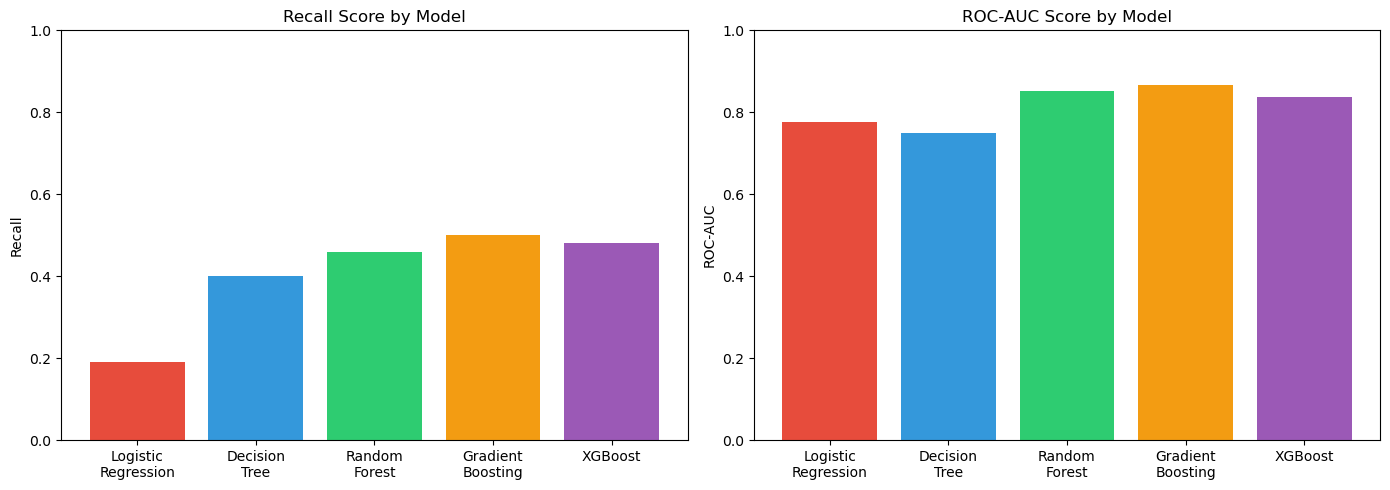

In [56]:
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting', 'XGBoost']
recall_scores = [0.19, 0.40, 0.46, 0.50, 0.48]
roc_scores = [0.7752, 0.75, 0.8531, 0.8675, 0.8377]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.bar(models, recall_scores, color=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'])
ax1.set_title('Recall Score by Model')
ax1.set_ylabel('Recall')
ax1.set_ylim(0,1)

ax2.bar(models, roc_scores, color=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'])
ax2.set_title('ROC-AUC Score by Model')
ax2.set_ylabel('ROC-AUC')
ax2.set_ylim(0,1)

plt.tight_layout()
plt.show()

### 7.2 Confusion Matrix

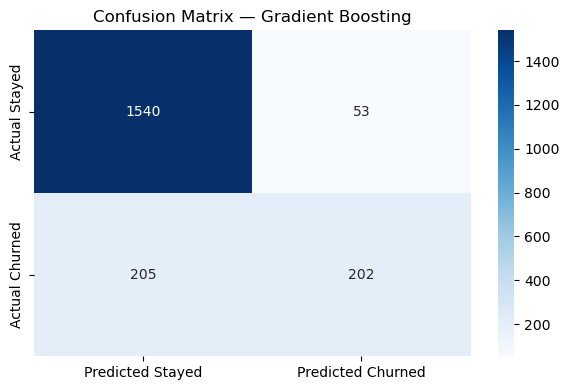

True Negatives (Correctly predicted stayed): 1540
False Positives (Said churn, actually stayed): 53
False Negatives (Missed churners): 205
True Positives (Correctly caught churners): 202


In [57]:
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed', 'Predicted Churned'],
            yticklabels=['Actual Stayed', 'Actual Churned'])
plt.title('Confusion Matrix — Gradient Boosting')
plt.tight_layout()
plt.show()

# Print what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Correctly predicted stayed): {tn}")
print(f"False Positives (Said churn, actually stayed): {fp}")
print(f"False Negatives (Missed churners): {fn}")
print(f"True Positives (Correctly caught churners): {tp}")

### 7.3 ROC Curve

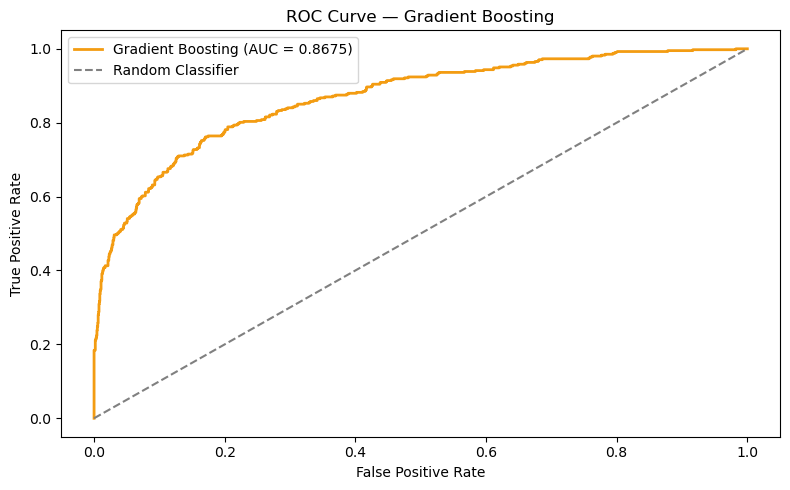

In [58]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='#f39c12', lw=2, label=f'Gradient Boosting (AUC = 0.8675)')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

## 8. SHAP Explainability

### 8.1 Import SHAP

In [59]:
import subprocess
subprocess.check_call(['pip', 'install', 'shap'])
import shap
print("SHAP imported successfully")

SHAP imported successfully


### 8.2 Feature Importance Plot

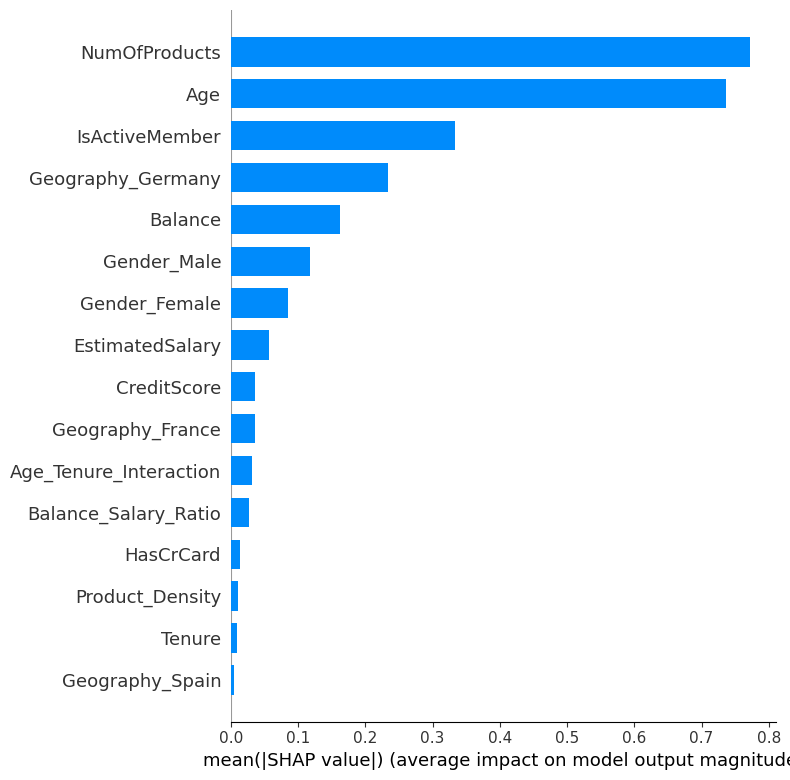

In [60]:
# Create SHAP explainer
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test)

# Feature importance plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

### 8.3 SHAP Summary Plot

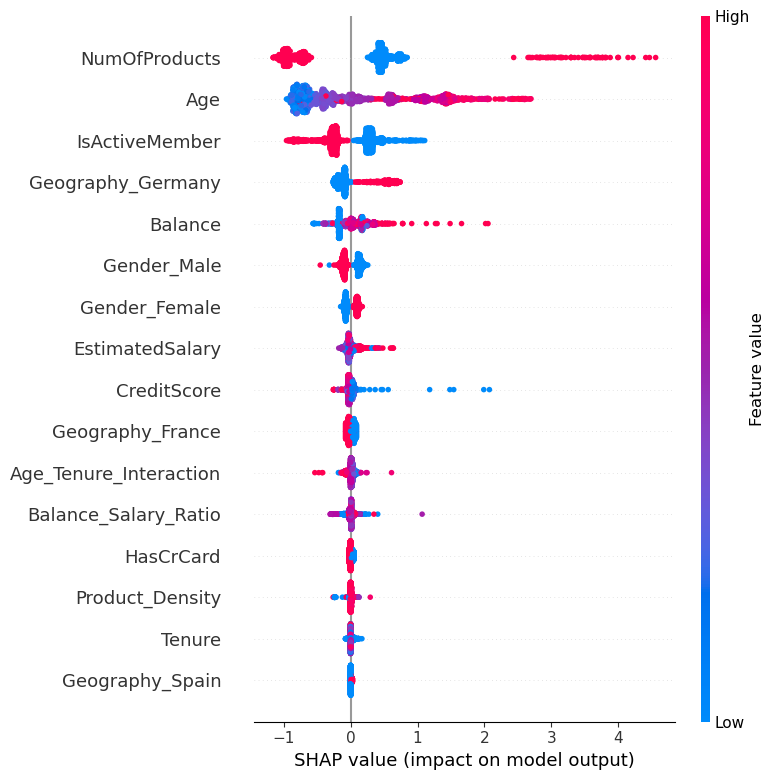

In [61]:
shap.summary_plot(shap_values, X_test, show=True)

## 9. Conclusion

### 9.1 Final Summary

In [62]:
print("""
PROJECT CONCLUSION
==================
Dataset: European Bank — 10,000 Customers
Target: Predict Customer Churn

KEY EDA FINDINGS:
- Overall churn rate: 20.37%
- Germany has highest churn rate: 32.4%
- Female customers churn more: 25% vs 16% male
- Age group 40-55 is highest risk
- Customers with 3-4 products: 83-100% churn rate
- Inactive members churn at 27% vs 14% active

BEST MODEL: Gradient Boosting
- Accuracy: 87%
- Recall: 50%
- ROC-AUC: 0.8675

TOP CHURN DRIVERS (SHAP):
1. NumOfProducts
2. Age
3. IsActiveMember
4. Geography_Germany
5. Balance
""")


PROJECT CONCLUSION
Dataset: European Bank — 10,000 Customers
Target: Predict Customer Churn

KEY EDA FINDINGS:
- Overall churn rate: 20.37%
- Germany has highest churn rate: 32.4%
- Female customers churn more: 25% vs 16% male
- Age group 40-55 is highest risk
- Customers with 3-4 products: 83-100% churn rate
- Inactive members churn at 27% vs 14% active

BEST MODEL: Gradient Boosting
- Accuracy: 87%
- Recall: 50%
- ROC-AUC: 0.8675

TOP CHURN DRIVERS (SHAP):
1. NumOfProducts
2. Age
3. IsActiveMember
4. Geography_Germany
5. Balance



### 9.2 Business Recommendations

In [63]:
print("""
BUSINESS RECOMMENDATIONS
========================
1. GERMANY INTERVENTION
   - Launch dedicated retention campaign in Germany
   - Investigate root cause — pricing, service quality, competition
   - Assign relationship managers to high-risk German customers

2. PRODUCT STRATEGY
   - Stop cross-selling beyond 2 products
   - Customers with 3-4 products need immediate attention
   - Focus on quality of products not quantity

3. AGE-BASED RETENTION
   - Create special offers for 40-55 age group
   - Better FD rates and wealth management services
   - This segment has highest savings — most valuable to retain

4. ENGAGEMENT PROGRAM
   - Re-engage inactive members immediately
   - Inactive members churn at 27% vs 14% active
   - Monthly touchpoints, personalized offers, loyalty rewards

5. GENDER-SPECIFIC STRATEGY
   - Female customers need targeted retention
   - 25% churn rate vs 16% male
   - Investigate service gaps affecting female customers

6. EARLY WARNING SYSTEM
   - Deploy churn probability scores monthly
   - Flag customers above 60% churn probability
   - Proactive outreach before they decide to leave
""")


BUSINESS RECOMMENDATIONS
1. GERMANY INTERVENTION
   - Launch dedicated retention campaign in Germany
   - Investigate root cause — pricing, service quality, competition
   - Assign relationship managers to high-risk German customers

2. PRODUCT STRATEGY
   - Stop cross-selling beyond 2 products
   - Customers with 3-4 products need immediate attention
   - Focus on quality of products not quantity

3. AGE-BASED RETENTION
   - Create special offers for 40-55 age group
   - Better FD rates and wealth management services
   - This segment has highest savings — most valuable to retain

4. ENGAGEMENT PROGRAM
   - Re-engage inactive members immediately
   - Inactive members churn at 27% vs 14% active
   - Monthly touchpoints, personalized offers, loyalty rewards

5. GENDER-SPECIFIC STRATEGY
   - Female customers need targeted retention
   - 25% churn rate vs 16% male
   - Investigate service gaps affecting female customers

6. EARLY WARNING SYSTEM
   - Deploy churn probability scores monthl

### 9.3 Limitations & Future Work

In [64]:
print("""
LIMITATIONS & FUTURE WORK
==========================
CURRENT LIMITATIONS:
- Recall of 50% means half of churners still missed
- Class imbalance not fully addressed
- No real-time data — static snapshot only
- Limited to 3 geographies
- No customer complaint or interaction data

FUTURE IMPROVEMENTS:
1. Apply SMOTE to handle class imbalance
2. Hyperparameter tuning for better recall
3. Add customer transaction history
4. Build real-time churn scoring pipeline
5. Include customer service interaction data
6. Deploy model via Streamlit dashboard

STREAMLIT APP:
- Customer risk calculator
- Input customer details
- Get instant churn probability
- What-if scenario simulator
""")


LIMITATIONS & FUTURE WORK
CURRENT LIMITATIONS:
- Recall of 50% means half of churners still missed
- Class imbalance not fully addressed
- No real-time data — static snapshot only
- Limited to 3 geographies
- No customer complaint or interaction data

FUTURE IMPROVEMENTS:
1. Apply SMOTE to handle class imbalance
2. Hyperparameter tuning for better recall
3. Add customer transaction history
4. Build real-time churn scoring pipeline
5. Include customer service interaction data
6. Deploy model via Streamlit dashboard

STREAMLIT APP:
- Customer risk calculator
- Input customer details
- Get instant churn probability
- What-if scenario simulator

